# Floating Water-Table Example (HYDRUS-1D via phydrus)

This notebook is the interactive version of `example_gw.py`.

Stages:
- Stage 1: constant-flux recharge, zero bottom flux, no roots
- Stage 2: atmospheric BC (Prec + rSoil), zero bottom flux
- Stage 3: atmospheric BC + shallow root uptake

In [1]:
from __future__ import annotations

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import phydrus as ps


def resolve_hydrus_exe() -> str:
    repo_root = Path.cwd().parents[0]
    for candidate in [
        repo_root / "hydrus1d" / "bin" / "hydrus",
        Path("/opt/hydrus1d/bin/hydrus"),
    ]:
        if candidate.exists():
            return str(candidate)
    raise FileNotFoundError("HYDRUS-1D executable not found.")


def hydrostatic_h(z: np.ndarray, z_wt: float) -> np.ndarray:
    return z_wt - z


def interpolate_gwl_from_nod_inf(nod: dict) -> pd.DataFrame:
    rows = []
    for t, df in sorted(nod.items()):
        z = df["Depth"].to_numpy(float)
        h = df["Head"].to_numpy(float)
        mask = ~(np.isnan(z) | np.isnan(h))
        z, h = z[mask], h[mask]
        order = np.argsort(z)
        z, h = z[order], h[order]

        if np.all(h > 0) or np.all(h < 0):
            rows.append((t, np.nan))
            continue

        idx = np.where(np.diff(np.signbit(h)))[0]
        if idx.size == 0:
            rows.append((t, np.nan))
            continue
        i = idx[-1]
        dh = h[i + 1] - h[i]
        z0 = z[i] if abs(dh) < 1e-12 else z[i] + (-h[i]) * (z[i + 1] - z[i]) / dh
        rows.append((t, z0))

    gwl = pd.DataFrame(rows, columns=["Time_d", "z_wt_cm"])
    gwl["depth_wt_cm"] = -gwl["z_wt_cm"]
    return gwl


Z_TOP = 0.0
Z_BOT = -300.0
Z_WT0 = -150.0
DX = 10.0

# Longer windows + moderate recharge: visibly rising WT, still stable.
TMAX_STAGE1 = 90
TMAX_STAGE2 = 120
TMAX_STAGE3 = 120

# Negative sign = downward flux at the top boundary.
RTOP = -0.50

OBS_Z = [-80.0, -150.0, -220.0]

In [2]:
def _build_base_model(ws: Path, title: str, tmax: int):
    ml = ps.Model(
        exe_name=resolve_hydrus_exe(),
        ws_name=str(ws),
        name="example_gw",
        description=title,
        mass_units="-",
        time_unit="days",
        length_unit="cm",
        print_screen=False,
    )
    ml.add_time_info(tinit=0, tmax=tmax, print_times=True, dt=0.05, dtmax=0.5, dtprint=1)
    return ml


def _add_material_profile_obs(ml):
    m = ml.get_empty_material_df(n=1)
    m.loc[1] = [0.078, 0.43, 0.036, 1.56, 24.96, 0.5]
    ml.add_material(m)

    profile = ps.create_profile(top=Z_TOP, bot=Z_BOT, dx=DX, mat=1)
    profile["h"] = hydrostatic_h(profile["x"].to_numpy(float), Z_WT0)
    ml.add_profile(profile)
    ml.add_obs_nodes(OBS_Z)
    return profile


def build_atmospheric_forcing(tmax: int, include_root: bool = False) -> pd.DataFrame:
    days = np.arange(1, tmax + 1, dtype=float)

    # Moderate wet bias: enough for visible WT rise without rapid full saturation.
    prec = 0.12 + 0.18 * (0.5 + 0.5 * np.sin(2.0 * np.pi * days / 14.0))
    storm = (days % 10 == 0).astype(float) * 0.20
    prec = prec + storm

    rsoil = 0.03 + 0.05 * (0.5 + 0.5 * np.sin(2.0 * np.pi * (days - 2.0) / 11.0))
    if include_root:
        rroot = 0.01 + 0.02 * (0.5 + 0.5 * np.sin(2.0 * np.pi * (days + 1.0) / 15.0))
    else:
        rroot = np.zeros_like(days)

    return pd.DataFrame(
        {
            "tAtm": days,
            "Prec": prec,
            "rSoil": rsoil,
            "rRoot": rroot,
            "hCritA": np.full_like(days, 1e5),
            "rB": np.zeros_like(days),
            "hB": np.zeros_like(days),
            "ht": np.zeros_like(days),
        }
    )


def run_stage1(ws: Path):
    ml = _build_base_model(ws, "Stage 1: constant recharge, zero bottom flux", TMAX_STAGE1)
    ml.add_waterflow(top_bc=1, bot_bc=1, rtop=RTOP, rbot=0.0, rroot=0.0, maxit=20, tolh=1.0, ha=1e-6, hb=1e4)
    profile = _add_material_profile_obs(ml)
    ml.write_input()
    result = ml.simulate()
    if result.returncode != 0:
        raise RuntimeError("HYDRUS run failed - see Error.msg in workspace.")
    return ml, profile


def run_stage2(ws: Path):
    ml = _build_base_model(ws, "Stage 2: atmospheric forcing, zero bottom flux", TMAX_STAGE2)
    ml.add_waterflow(top_bc=3, bot_bc=1, rbot=0.0, rroot=0.0, maxit=20, tolh=1.0, ha=1e-6, hb=1e4)
    profile = _add_material_profile_obs(ml)
    atm = build_atmospheric_forcing(tmax=TMAX_STAGE2, include_root=False)
    atm.to_csv(ws / "atmospheric_forcing.csv", index=False)
    ml.add_atmospheric_bc(atm)
    ml.write_input()
    result = ml.simulate()
    if result.returncode != 0:
        raise RuntimeError("HYDRUS run failed in Stage 2 - see Error.msg.")
    return ml, profile


def run_stage3(ws: Path):
    ml = _build_base_model(ws, "Stage 3: atmospheric forcing + shallow root uptake", TMAX_STAGE3)
    ml.add_waterflow(top_bc=3, bot_bc=1, rbot=0.0, rroot=0.0, maxit=20, tolh=1.0, ha=1e-6, hb=1e4)
    profile = _add_material_profile_obs(ml)
    atm = build_atmospheric_forcing(tmax=TMAX_STAGE3, include_root=True)
    atm.to_csv(ws / "atmospheric_forcing.csv", index=False)
    ml.add_atmospheric_bc(atm)
    ml.add_root_uptake(model=0, poptm=[-25], p0=-10, p2h=-200, p2l=-800, p3=-8000)
    ml.add_root_growth(
        irootin=2, irfak=1, trmin=0, trmed=0, trmax=TMAX_STAGE3, xrmin=5, xrmed=0, xrmax=60, trperiod=365
    )
    ml.write_input()
    result = ml.simulate()
    if result.returncode != 0:
        raise RuntimeError("HYDRUS run failed in Stage 3 - see Error.msg.")
    return ml, profile

In [3]:
def postprocess(ml, profile: pd.DataFrame, ws: Path, stage: int) -> None:
    tlevel = ml.read_tlevel()
    tlevel.to_csv(ws / "tlevel.csv")

    nod = ml.read_nod_inf()
    if isinstance(nod, pd.DataFrame):
        nod = {0.0: nod}
    gwl = interpolate_gwl_from_nod_inf(nod)
    gwl.to_csv(ws / "gwl_timeseries.csv", index=False)

    last_t = max(nod.keys())
    nod[last_t].to_csv(ws / "nod_inf_last.csv", index=False)

    obs_z = [-80.0, -150.0, -220.0]
    heads_list = []
    for z_target in obs_z:
        series = pd.Series(
            {t: float(df.loc[(df["Depth"] - z_target).abs().idxmin(), "Head"]) for t, df in nod.items()},
            name=f"h_z{int(abs(z_target))}cm",
        )
        heads_list.append(series)
    head_df = pd.concat(heads_list, axis=1)
    head_df.index.name = "Time_d"
    head_df.to_csv(ws / "obs_heads.csv")

    bot_h = pd.Series(
        {t: float(df.loc[df["Depth"].abs().idxmax(), "Head"]) for t, df in nod.items()}, name="h_bottom_cm"
    )
    bot_h.to_csv(ws / "bottom_head_check.csv", index_label="Time_d")

    fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
    fig.suptitle(f"Stage {stage}: floating water-table (zero bottom flux)")

    ax = axes[0]
    ax.plot(gwl["Time_d"], gwl["depth_wt_cm"], lw=2, color="tab:blue")
    ax.invert_yaxis()
    ax.set(xlabel="Time [days]", ylabel="WT depth below surface [cm]", title="Water-table trajectory")
    ax.grid(alpha=0.3)

    ax = axes[1]
    for col in head_df.columns:
        label = col.replace("h_z", "z=-").replace("cm", " cm")
        ax.plot(head_df.index, head_df[col], label=label)
    ax.axhline(0, color="k", ls="--", lw=1, label="h=0 (WT)")
    ax.set(xlabel="Time [days]", ylabel="h [cm]", title="Pressure heads at selected depths")
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

    ax = axes[2]
    for col, label, color in [("vTop", "vTop (actual)", "tab:blue"), ("vBot", "vBot (≈0 sealed base)", "tab:orange")]:
        if col in tlevel.columns:
            ax.plot(tlevel.index, tlevel[col], label=label, color=color)
    ax.axhline(0, color="k", lw=0.8)
    ax.set(xlabel="Time [days]", ylabel="Flux [cm/day]", title="Boundary fluxes")
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

    fig.tight_layout()
    fig.savefig(ws / f"stage{stage}_overview.png", dpi=150)
    plt.close(fig)

    summary = pd.Series(
        {
            "stage": stage,
            "wt_initial_cm": Z_WT0,
            "wt_depth_start_cm": float(gwl["depth_wt_cm"].iloc[0]),
            "wt_depth_end_cm": float(gwl["depth_wt_cm"].iloc[-1]),
            "wt_depth_min_cm": float(gwl["depth_wt_cm"].min(skipna=True)),
            "wt_depth_max_cm": float(gwl["depth_wt_cm"].max(skipna=True)),
            "wt_excursion_cm": float(gwl["depth_wt_cm"].max(skipna=True) - gwl["depth_wt_cm"].min(skipna=True)),
            "wt_rise_from_init_cm": float(abs(Z_WT0) - gwl["depth_wt_cm"].min()),
            "bottom_h_min_cm": float(bot_h.min(skipna=True)),
            "bottom_h_max_cm": float(bot_h.max(skipna=True)),
            "bottom_stayed_sat": bool(bot_h.min(skipna=True) > 0),
            "vBot_mean_cm_d": float(tlevel["vBot"].mean()) if "vBot" in tlevel.columns else float("nan"),
            "vBot_maxabs_cm_d": float(tlevel["vBot"].abs().max()) if "vBot" in tlevel.columns else float("nan"),
        }
    )
    summary.to_csv(ws / "analysis_summary.csv", header=["value"])
    print(summary.to_string())


def compare_stages(base_ws: Path) -> None:
    rows = []
    for stage in (1, 2, 3):
        ws = base_ws / f"stage{stage}"
        s = pd.read_csv(ws / "analysis_summary.csv", index_col=0).iloc[:, 0]
        s.name = f"stage{stage}"
        rows.append(s)

    compare = pd.DataFrame(rows)
    compare.to_csv(base_ws / "stage_comparison.csv")

    fig, ax = plt.subplots(1, 1, figsize=(7, 4))
    for stage in (1, 2, 3):
        ws = base_ws / f"stage{stage}"
        gwl = pd.read_csv(ws / "gwl_timeseries.csv")
        ax.plot(gwl["Time_d"], gwl["depth_wt_cm"], lw=2, label=f"Stage {stage}")
    ax.invert_yaxis()
    ax.set(xlabel="Time [days]", ylabel="WT depth below surface [cm]", title="WT trajectory by stage")
    ax.legend()
    ax.grid(alpha=0.3)
    fig.tight_layout()
    fig.savefig(base_ws / "stage_comparison_wt.png", dpi=150)
    plt.close(fig)

In [4]:
base_ws = Path.cwd() / "example_gw"
base_ws.mkdir(parents=True, exist_ok=True)

print("=== Stage 1: constant recharge, zero bottom flux, no roots ===")
ws1 = base_ws / "stage1"
ws1.mkdir(parents=True, exist_ok=True)
ml1, profile1 = run_stage1(ws1)
postprocess(ml1, profile1, ws1, stage=1)

print("=== Stage 2: atmospheric forcing, zero bottom flux, no roots ===")
ws2 = base_ws / "stage2"
ws2.mkdir(parents=True, exist_ok=True)
ml2, profile2 = run_stage2(ws2)
postprocess(ml2, profile2, ws2, stage=2)

print("=== Stage 3: atmospheric forcing + shallow roots ===")
ws3 = base_ws / "stage3"
ws3.mkdir(parents=True, exist_ok=True)
ml3, profile3 = run_stage3(ws3)
postprocess(ml3, profile3, ws3, stage=3)

compare_stages(base_ws)
print(f"\nOutputs written to: {base_ws}")

INFO: Successfully wrote /Users/veethahavya/Desktop/phydrus/examples/example_gw/stage1/SELECTOR.IN
INFO: Successfully wrote /Users/veethahavya/Desktop/phydrus/examples/example_gw/stage1/PROFILE.DAT


=== Stage 1: constant recharge, zero bottom flux, no roots ===
  The numerical solution has not converged ! 
  The numerical solution has not converged ! 
  The numerical solution has not converged ! 
  The numerical solution has not converged ! 
  The numerical solution has not converged ! 
  The numerical solution has not converged ! 
  The numerical solution has not converged ! 
  The numerical solution has not converged ! 
  The numerical solution has not converged ! 
  The numerical solution has not converged ! 
  The numerical solution has not converged ! 
  The numerical solution has not converged ! 
  The numerical solution has not converged ! 
  The numerical solution has not converged ! 
  The numerical solution has not converged ! 
  The numerical solution has not converged ! 
  The numerical solution has not converged ! 
  The numerical solution has not converged ! 
  The numerical solution has not converged ! 
  The numerical solution has not converged ! 
  The numerical s

INFO: Hydrus-1D Simulation Successful.


  The numerical solution has not converged ! 
  The numerical solution has not converged ! 
  The numerical solution has not converged ! 
  The numerical solution has not converged ! 
  The numerical solution has not converged ! 
  The numerical solution has not converged ! 
  The numerical solution has not converged ! 
  The numerical solution has not converged ! 
  The numerical solution has not converged ! 
  The numerical solution has not converged ! 
  The numerical solution has not converged ! 
  The numerical solution has not converged ! 
  The numerical solution has not converged ! 
  The numerical solution has not converged ! 
  The numerical solution has not converged ! 
  The numerical solution has not converged ! 
  The numerical solution has not converged ! 
  The numerical solution has not converged ! 
  The numerical solution has not converged ! 
  The numerical solution has not converged ! 
  The numerical solution has not converged ! 
  The numerical solution has not c

INFO: Successfully wrote /Users/veethahavya/Desktop/phydrus/examples/example_gw/stage2/SELECTOR.IN
INFO: Successfully wrote /Users/veethahavya/Desktop/phydrus/examples/example_gw/stage2/PROFILE.DAT
INFO: Successfully wrote /Users/veethahavya/Desktop/phydrus/examples/example_gw/stage2/ATMOSPH.IN
INFO: Hydrus-1D Simulation Successful.


stage                          1
wt_initial_cm             -150.0
wt_depth_start_cm          150.0
wt_depth_end_cm            0.034
wt_depth_min_cm            0.012
wt_depth_max_cm            150.0
wt_excursion_cm          149.988
wt_rise_from_init_cm     149.988
bottom_h_min_cm            150.0
bottom_h_max_cm          301.076
bottom_stayed_sat           True
vBot_mean_cm_d               0.0
vBot_maxabs_cm_d        0.000039
=== Stage 2: atmospheric forcing, zero bottom flux, no roots ===


INFO: Successfully wrote /Users/veethahavya/Desktop/phydrus/examples/example_gw/stage3/SELECTOR.IN
INFO: Successfully wrote /Users/veethahavya/Desktop/phydrus/examples/example_gw/stage3/PROFILE.DAT
INFO: Successfully wrote /Users/veethahavya/Desktop/phydrus/examples/example_gw/stage3/ATMOSPH.IN
INFO: Hydrus-1D Simulation Successful.


stage                          2
wt_initial_cm             -150.0
wt_depth_start_cm          150.0
wt_depth_end_cm           14.259
wt_depth_min_cm           14.259
wt_depth_max_cm            150.0
wt_excursion_cm          135.741
wt_rise_from_init_cm     135.741
bottom_h_min_cm            150.0
bottom_h_max_cm          285.741
bottom_stayed_sat           True
vBot_mean_cm_d          0.000001
vBot_maxabs_cm_d        0.000039
=== Stage 3: atmospheric forcing + shallow roots ===
stage                       3
wt_initial_cm          -150.0
wt_depth_start_cm       150.0
wt_depth_end_cm          45.8
wt_depth_min_cm          45.8
wt_depth_max_cm         150.0
wt_excursion_cm         104.2
wt_rise_from_init_cm    104.2
bottom_h_min_cm         150.0
bottom_h_max_cm         254.2
bottom_stayed_sat        True
vBot_mean_cm_d            0.0
vBot_maxabs_cm_d          0.0

Outputs written to: /Users/veethahavya/Desktop/phydrus/examples/example_gw


## Post-Simulation Node Diagnostics

This section plots, for each stage and key observation node:
- matric pressure head $h$ [cm] versus time
- saturation $S = \theta/\theta_s$ [-] versus time

Key node depths are taken from `OBS_Z`.

In [5]:
# Switch to inline plotting for notebook display
import matplotlib.pyplot as plt

plt.switch_backend("module://matplotlib_inline.backend_inline")

In [6]:
import re


def _node_depth_from_col(col: str) -> float:
    m = re.search(r"h_z(\d+)cm", col)
    if m is None:
        raise ValueError(f"Cannot parse node depth from column: {col}")
    return -float(m.group(1))


def _load_stage_heads(base_ws: Path, stage: int) -> pd.DataFrame:
    ws = base_ws / f"stage{stage}"
    heads = pd.read_csv(ws / "obs_heads.csv", index_col=0)
    heads.index = heads.index.astype(float)
    return heads


def _load_stage_initial_final(stage: int) -> tuple[pd.DataFrame, pd.DataFrame]:
    models = {1: ml1, 2: ml2, 3: ml3}
    nod = models[stage].read_nod_inf()
    if isinstance(nod, pd.DataFrame):
        nod = {0.0: nod}
    times = sorted(nod.keys())
    ini = nod[times[0]].copy()
    fin = nod[times[-1]].copy()
    for df in (ini, fin):
        df.dropna(subset=["Depth", "Head", "Moisture"], inplace=True)
        df.sort_values("Depth", inplace=True)
    return ini, fin


if "base_ws" not in globals():
    raise RuntimeError("Run the stage simulation cell first to create base_ws and stage outputs.")

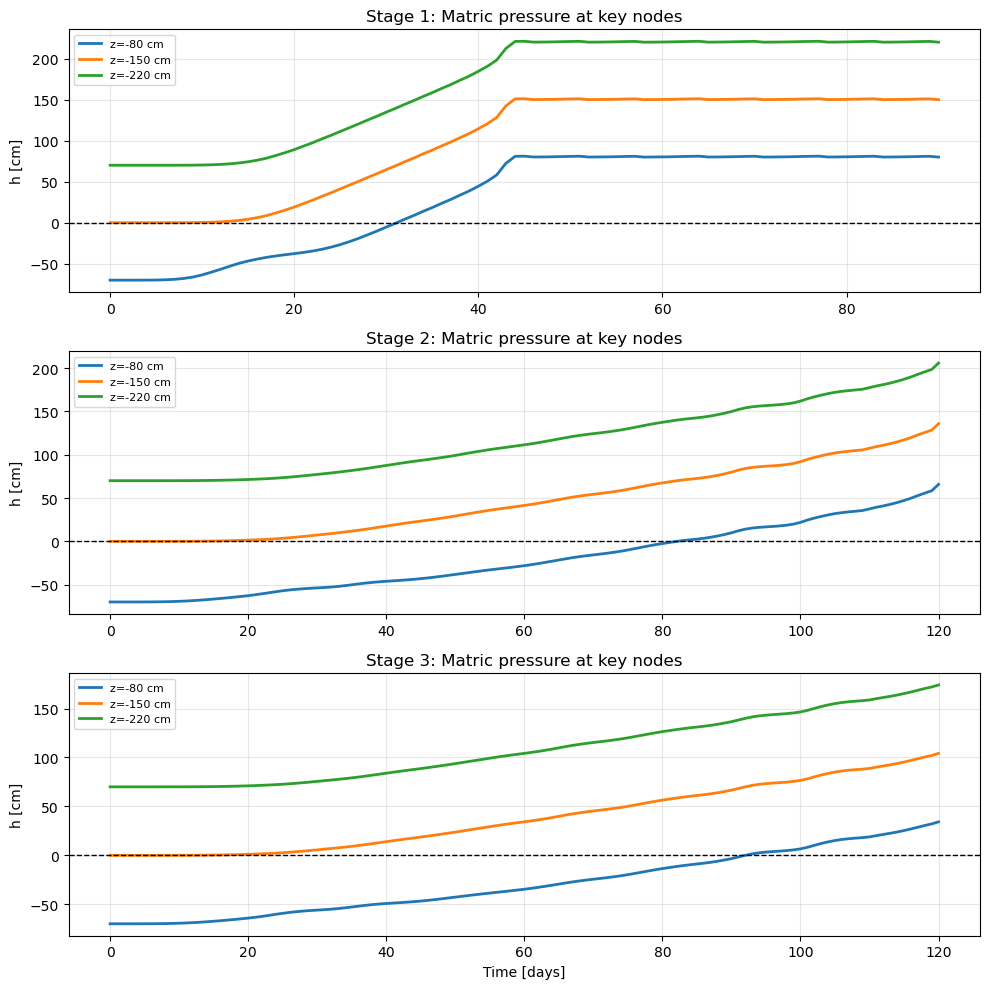

In [7]:
# Plot 1: matric pressure head h(t) at key nodes (one figure)
fig, axes = plt.subplots(3, 1, figsize=(10, 10), sharex=False)
for i, stage in enumerate((1, 2, 3)):
    heads = _load_stage_heads(base_ws, stage)
    ax = axes[i]
    for col in heads.columns:
        z = _node_depth_from_col(col)
        if z not in OBS_Z:
            continue
        ax.plot(heads.index, heads[col].astype(float), lw=2, label=f"z={z:.0f} cm")
    ax.axhline(0.0, color="k", ls="--", lw=1)
    ax.set_title(f"Stage {stage}: Matric pressure at key nodes")
    ax.set_ylabel("h [cm]")
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8, loc="best")
axes[-1].set_xlabel("Time [days]")
fig.tight_layout()
plt.show()

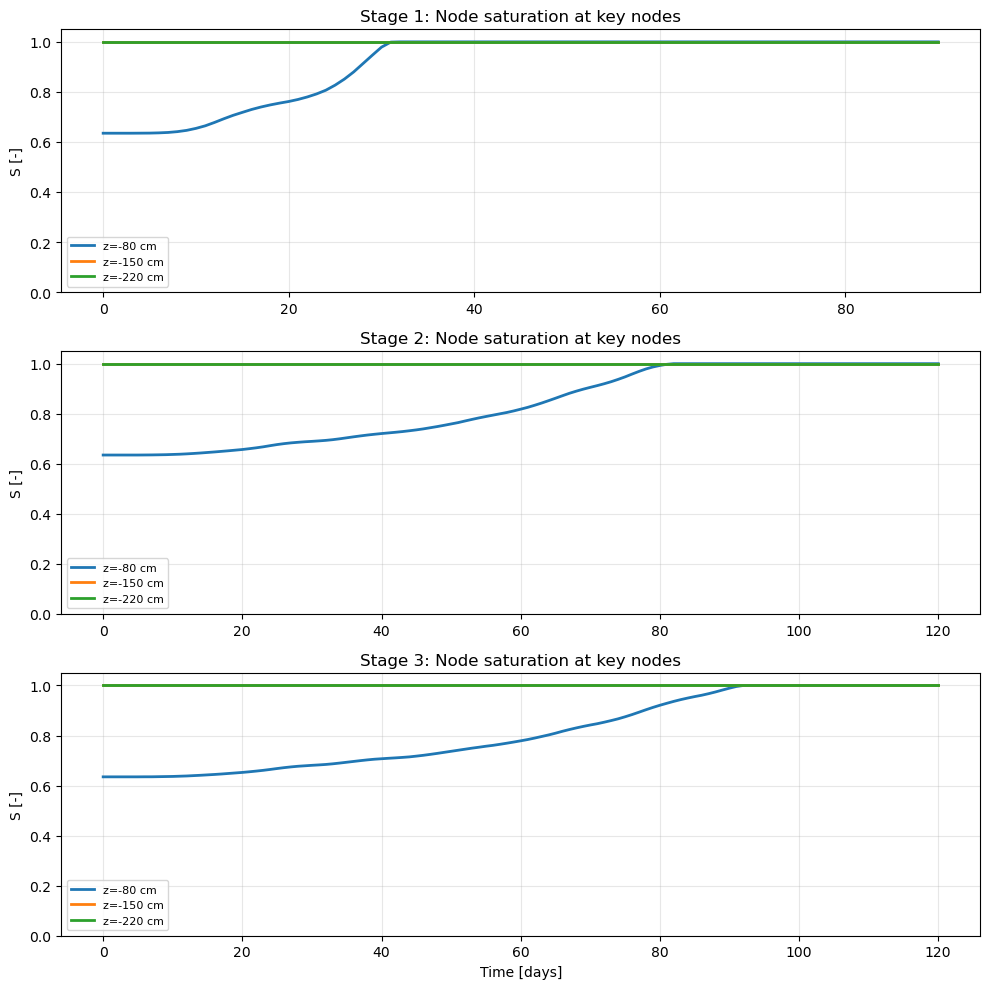

In [8]:
# Plot 2: node saturation S(t) at key nodes (one figure)
theta_s = 0.43
models = {1: ml1, 2: ml2, 3: ml3}

fig, axes = plt.subplots(3, 1, figsize=(10, 10), sharex=False)
for i, stage in enumerate((1, 2, 3)):
    nod = models[stage].read_nod_inf()
    if isinstance(nod, pd.DataFrame):
        nod = {0.0: nod}

    times = sorted(nod.keys())
    ax = axes[i]
    for z in OBS_Z:
        s_vals = []
        for t in times:
            df = nod[t].dropna(subset=["Depth", "Moisture"]).copy()
            idx = (df["Depth"].astype(float) - z).abs().idxmin()
            theta = float(df.loc[idx, "Moisture"])
            s_vals.append(theta / theta_s)
        ax.plot(times, s_vals, lw=2, label=f"z={z:.0f} cm")

    ax.set_title(f"Stage {stage}: Node saturation at key nodes")
    ax.set_ylabel("S [-]")
    ax.set_ylim(0.0, 1.05)
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8, loc="best")

axes[-1].set_xlabel("Time [days]")
fig.tight_layout()
plt.show()

## Initial vs Final Profile Diagnostics

The next two cells add one plot per cell for:
- matric pressure profile $h(z)$
- saturation profile $S(z)$ with $S = \theta / \theta_s$ and $\theta_s=0.43$ for the loam material.

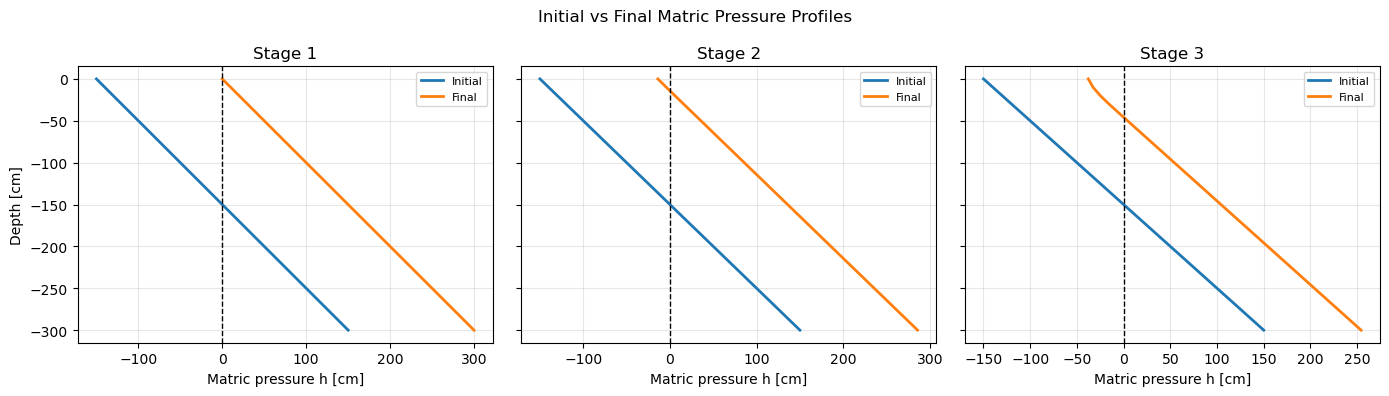

In [9]:
# Plot 3: initial vs final matric pressure profiles (one figure)
fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)
for i, stage in enumerate((1, 2, 3)):
    ini, fin = _load_stage_initial_final(stage)
    ax = axes[i]
    ax.plot(ini["Head"].astype(float), ini["Depth"].astype(float), lw=2, label="Initial")
    ax.plot(fin["Head"].astype(float), fin["Depth"].astype(float), lw=2, label="Final")
    ax.axvline(0.0, color="k", ls="--", lw=1)
    ax.set_title(f"Stage {stage}")
    ax.set_xlabel("Matric pressure h [cm]")
    ax.grid(alpha=0.3)
    if i == 0:
        ax.set_ylabel("Depth [cm]")
    ax.legend(fontsize=8, loc="best")
fig.suptitle("Initial vs Final Matric Pressure Profiles")
fig.tight_layout()
plt.show()

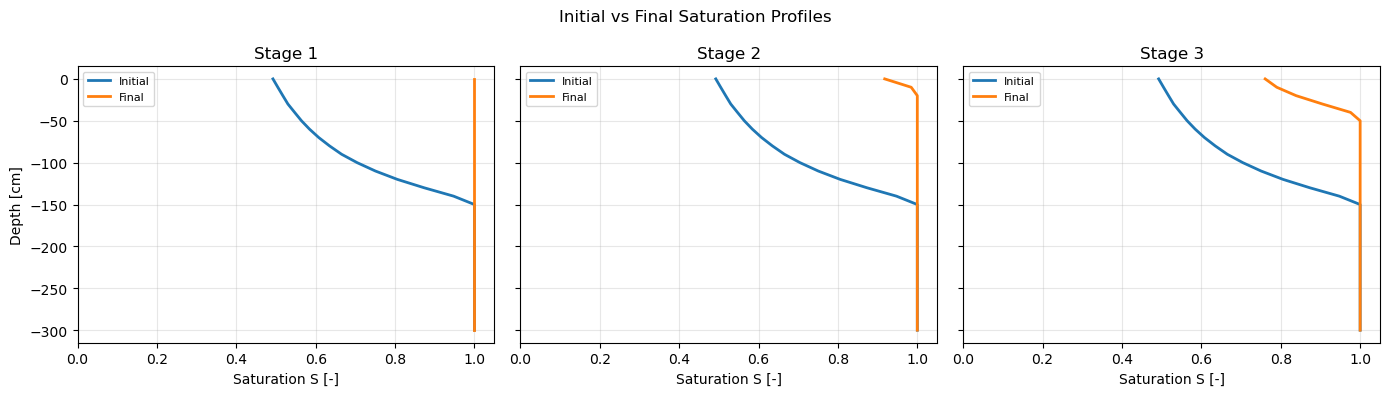

In [10]:
# Plot 4: initial vs final saturation profiles (one figure)
theta_s = 0.43
fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)
for i, stage in enumerate((1, 2, 3)):
    ini, fin = _load_stage_initial_final(stage)
    s_ini = ini["Moisture"].astype(float) / theta_s
    s_fin = fin["Moisture"].astype(float) / theta_s

    ax = axes[i]
    ax.plot(s_ini, ini["Depth"].astype(float), lw=2, label="Initial")
    ax.plot(s_fin, fin["Depth"].astype(float), lw=2, label="Final")
    ax.set_title(f"Stage {stage}")
    ax.set_xlabel("Saturation S [-]")
    ax.set_xlim(0.0, 1.05)
    ax.grid(alpha=0.3)
    if i == 0:
        ax.set_ylabel("Depth [cm]")
    ax.legend(fontsize=8, loc="best")
fig.suptitle("Initial vs Final Saturation Profiles")
fig.tight_layout()
plt.show()